# BCGs in Relaxed and Unrelaxed Halos

Using structured collections allows us to do more complicated analysis tasks with simulation particle data. To show what we mean, lets use a structured collection with halo properties and particles to do some comparisons between the galaxies in relaxed and unrelaxed halos.

- Divide halos into relaxed and unrelaxed subsets
- Look at their brightest cluster galaxies
- Investigate the brightest cluster galaxy properties

<div class="meta-block">
  <div class="meta-row">
    <span class="meta-label">Data</span>
    <span class="chip chip-data">Halo Properties</span>
    <span class="chip chip-data">Halo Particles</span>
    <span class="chip chip-data">Linked Datasets</span>
  </div>
  <div class="meta-row">
    <span class="meta-label">Tasks</span>
    <span class="chip chip-task">Query</span>
    <span class="chip chip-task">Select</span>
    <span class="chip chip-task">Filter</span>
    <span class="chip chip-task">Add Columns</span>
    <span class="chip chip-task">Evaluate</span>
  </div>
</div>

In [6]:
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt

## Filtering for Halo Relaxation

<details>
<summary><b>Brief Recap - Halo Relaxation</b></summary>

A relaxed dark matter halo is a halo that is in virial equilibrium. As such, it is stable, in a sense: you won't see it contracting or expanding, and its density profile will be mostly smooth. Halos can become unrelaxed through violent events like mergers, which breaks virial equilibrium and create substantial substructure in the halo.

The typical way to determine if a halo is relaxed or not, is to look at the offset between the halo center of mass ($r_{com}$) and the potential minimum of the halo ($r_{min}$). A virialized object will have a low offset because the most massive objects will settle in the center of the halo. Meanwhile, if a halo is unrelaxed due to a merger, the offset will be larger. The exact criteria to call a halo relaxed is as follows, where $R_{200,c}$ is the virial radius of the halo:

$$ 0.07 > \frac{||r_{min} - r_{com}||}{R_{200,c}}$$

</details>


As always, let's start by loading some data. The following line will load a file with both halo properties and particles. This creates a "Structured Collection" (for more see [here](https://opencosmo.readthedocs.io/en/stable/collections.html)), where OpenCosmo will automatically pair particles with their assigned halo, making the process of dealing with halo particles simple for the user.

In [7]:
data = oc.open('halo_properties_particles.hdf5')

First, we have to make a new column with the offset between $r_{min}$, the potential minimum, and $r_{com}$, the center of mass. This can be done using `.with_new_columns()`. Note that we have to specify the dataset we want to add the column to. This is because the Structured Collection has combined a `halo_properties` dataset with multiple halo particle datasets (`star_particles`, `gas_particles`, etc.), and the column could be added to any of these datasets. We will add our column to the `halo_properties` dataset since the relaxation state is per-halo, rather than per-particle.

In [8]:
#make new column
dist = np.sqrt((oc.col('fof_halo_center_x') - oc.col('fof_halo_com_x'))**2 + 
               (oc.col('fof_halo_center_y') - oc.col('fof_halo_com_y'))**2 + 
               (oc.col('fof_halo_center_z') - oc.col('fof_halo_com_z'))**2 ) #compute distance
dist = dist / oc.col('sod_halo_RVir') # divide by virial radius

#add to dataset
data = data.with_new_columns(dataset="halo_properties", r_offset = dist) #r_offset becomes the name of the column.

<details>
<summary><b>Your Turn - `offset_3d`</b></summary>

If the above process is too long and clunky for your tastes, you can instead import and use the [`offset_3d`](https://opencosmo.readthedocs.io/en/stable/column_ref.html#opencosmo.column.offset_3d) function. Try using it to recreate the above column as practice!

</details>

Now we can easily use the column to break up our data into relaxed and unrelaxed. This involves two calls to `.filter()` to make two new datasets. 

In [9]:
d_relax = data.filter(oc.col('r_offset') < 0.07) #relaxed
d_unrelax = data.filter(oc.col('r_offset') > 0.07) #unrelaxed

Now let's make some plots! We can start with something more straightforward, and look at the mass of the halos. We can also print the fraction of relaxed objects to see if we are getting reasonable results. 
This plot will only require us to use a `.select()` column query on the halo_properties dataset, no particles needed yet! See how it is done below:

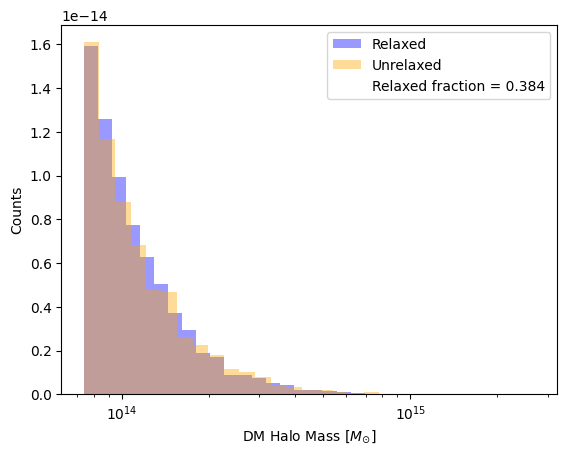

In [10]:
# fraction of relaxed halos
f = len(d_relax)/(len(d_unrelax) + len(d_relax))

# select desired column, and use .get_data() for an astropy array
M_rel = d_relax['halo_properties'].select('sod_halo_mass').get_data().value
M_unrel = d_unrelax['halo_properties'].select('sod_halo_mass').get_data().value

#plot relaxed
bins = np.logspace(np.min(np.log10(M_rel)),np.max(np.log10(M_rel)),30)
plt.hist(M_rel, bins = bins, alpha = 0.4, label = f'Relaxed', density = True, color = 'blue')

#plot unrelaxed
bins = np.logspace(np.min(np.log10(M_unrel)),np.max(np.log10(M_unrel)),30)
plt.hist(M_unrel, bins = bins, alpha = 0.4, label = f'Unrelaxed', density = True, color = 'orange')

plt.plot([], [], ' ', label=f"Relaxed fraction = {f:.3f}")
plt.xscale('log')
plt.xlabel('DM Halo Mass [$M_{\odot}$]')
plt.ylabel('Counts')
plt.legend()
plt.show()

Our mass distribution and relaxed halo fraction is in line with what we expect!

## BCG Properties

We aren't restricted to only halo properties when using a structured collection, we also have access to particle data. Let's use those particles to investigate the Brightest Cluster Galaxy (BCG).

### Using Star Particles

We expect BCGs to have slightly different mass distributions based on the relaxation state of the cluster. To show this, let's put a 50 kpc aperture around the potential minimum of the cluster and calculate the mass of that central galaxy using star particles.

Making a new column with the mass of the BCG will be a more complicated task, so we will forgo using `.with_new_columns()` and instead use `.evaluate()`. Evaluate takes a function of the user's creation and can return the output of that function as a new column in the dataset. For Structured Collections, the function should always have the properties and particles needed for the calculation as input. Hence why our function below only has `halo_properties` and `star_particles` as input. From here you write the function as normal and return a dictionary, where the key will be the name of the new column and the value will be the data in the column. When writing the function, you can refer to specific columns by using the column name outright, no need for `.select()` or `.col()`.

In [11]:
#Function to compute mass of BCG
def Central_Mass(halo_properties, star_particles): #particles/properties are the arguments
    
    #get particle positions, mass, and halo center using column names
    pos = np.vstack((star_particles['x'],star_particles['y'],star_particles['z'])).T 
    pmass = star_particles['mass']
    fof_cen = np.array([halo_properties['fof_halo_center_x'], halo_properties['fof_halo_center_y'], halo_properties['fof_halo_center_z']])
    
    #compute particle distances
    dists = np.sqrt( np.sum((pos - fof_cen)**2, axis = 1) )
    
    #sum the mass of particles within the aperture
    mass = np.sum(pmass[dists < 0.05])
    
    #return dictionary where key (BCG_mass) is new column name
    return {'BCG_mass' : mass}

In our call to `.evaluate()`, we need to make sure to provide the function name, specify what columns the function uses from each dataset, decide the format of the data (numpy or astropy), and determine whether or not we want the column(s) inserted into the dataset. Make sure to always set `insert = True` so that your new column makes it into your datasets. By default, new columns will be added to the properities dataset.

<details>
<summary><b>Tip: Read The Docs!</b></summary>

`.evaluate()` is a super powerful and useful function for more complicated analyses. Our tutorial of it here only scratches the surface of how it can be used. We encourage you to [read the docs](https://opencosmo.readthedocs.io/en/stable/evaluating.html) to get a better sense of how it can help you do cool science!

</details>

In [12]:
d_relax = d_relax.evaluate(Central_Mass, 
                            star_particles = ['x', 'y', 'z', 'mass'], 
                            halo_properties = ['fof_halo_center_x', 'fof_halo_center_y','fof_halo_center_z'], 
                            format = 'numpy', 
                            insert = True)

d_unrelax = d_unrelax.evaluate(Central_Mass, 
                            star_particles = ['x', 'y', 'z', 'mass'], 
                            halo_properties = ['fof_halo_center_x', 'fof_halo_center_y','fof_halo_center_z'], 
                            format = 'numpy', 
                            insert = True)

Now we can use that column just like any other and call `.select()` and `.get_data()` to extract the column data and plot.

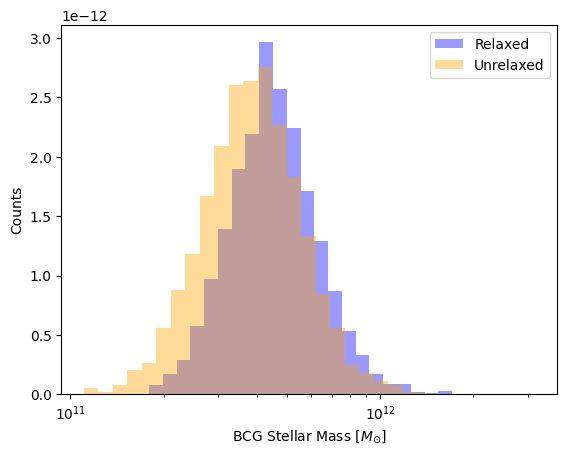

In [13]:
#extract columns
BCG_rel = d_relax['halo_properties'].select('BCG_mass').get_data()
BCG_unrel = d_unrelax['halo_properties'].select('BCG_mass').get_data()

#plot
bins = np.logspace(np.min(np.log10(BCG_rel)),np.max(np.log10(BCG_rel)),30)
plt.hist(BCG_rel, bins = bins, alpha = 0.4, label = 'Relaxed', density = True, color = 'blue')
bins = np.logspace(np.min(np.log10(BCG_unrel)),np.max(np.log10(BCG_unrel)),30)
plt.hist(BCG_unrel, bins = bins, alpha = 0.4, label = 'Unrelaxed', density = True, color = 'orange')
plt.xscale('log')
plt.xlabel('BCG Stellar Mass [$M_{\odot}$]')
plt.ylabel('Counts')
plt.legend()
plt.show()

Notice how the mass distribution of BCGs in unrelaxed halos is peaked at a slighly lower stellar mass! We can even take this a step further and plot the Stellar Mass - Halo Mass relation for these BCGs. We have all the data we need, so we just need to plot it:

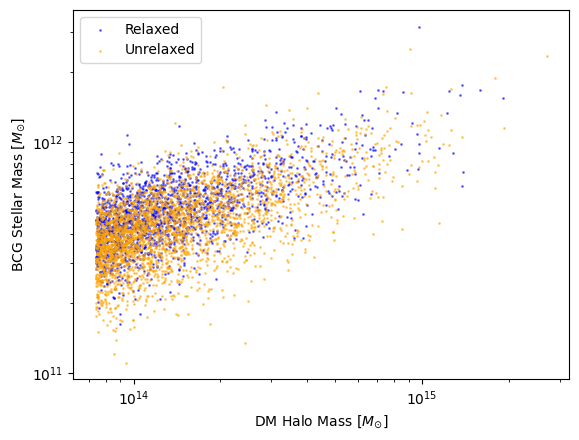

In [14]:
plt.scatter(M_rel, BCG_rel, label = 'Relaxed', color = 'blue', s = 1, alpha = 0.5)
plt.scatter(M_unrel, BCG_unrel, label = 'Unrelaxed', color = 'orange', s = 1, alpha = 0.5)
plt.ylabel('BCG Stellar Mass [$M_{\odot}$]')
plt.xlabel('DM Halo Mass [$M_{\odot}$]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

### Adding in Gas Particles

We will incorporate gas particles into our final plots by looking at the bulk motion of stars compared to gas in the BCG. While we are at it, we can also compute the BCG velocity dispersion.

To make these columns we call `.evaluate()` as before, but now we also provide `gas_particles` as an input for the function and specify the columns we need for our calculation. Note also how our dictionary now has 4 entries, since we want to add 4 new columns to our dataset. Once again, the name of each column will be the key of each dictionary entry.

> **Note:**
>
> If running live, this cell may take a while to run!

In [ ]:
#This cell may take a while to run since we have a lot of data, ~a few minutes!
def Central_V(halo_properties, star_particles, gas_particles):
    
    #get particle positions, velocity, etc
    pos = np.vstack((star_particles['x'],star_particles['y'],star_particles['z'])).T
    vel = np.vstack((star_particles['vx'],star_particles['vy'],star_particles['vz'])).T #now we ask for velocity too
    fof_cen = np.array([halo_properties['fof_halo_center_x'], halo_properties['fof_halo_center_y'], halo_properties['fof_halo_center_z']])
    pmass = star_particles['mass']
    
    #make aperture mask
    dists = np.sqrt( np.sum((pos - fof_cen)**2, axis = 1) )
    mask = dists <= 0.05
    
    #mass weighted velocity dispersion and mean motion
    vm_stars = np.average(vel[mask], axis = 0, weights = pmass[mask])
    vd = np.average((vel[mask] - vm_stars)**2, axis = 0, weights = pmass[mask])
    vd_stars = np.sqrt(np.sum(vd))
    
    #repeat for gas
    pos = np.vstack((gas_particles['x'],gas_particles['y'],gas_particles['z'])).T
    vel = np.vstack((gas_particles['vx'],gas_particles['vy'],gas_particles['vz'])).T
    pmass = gas_particles['mass']
    
    dists = np.sqrt( np.sum((pos - fof_cen)**2, axis = 1) )
    mask = dists <= 0.05
    
    vm_gas = np.average(vel[mask], axis = 0, weights = pmass[mask])
    vd = np.average((vel[mask] - vm_stars)**2, axis = 0, weights = pmass[mask])
    vd_gas = np.sqrt(np.sum(vd))
    
    #return dictionary with 4 entries for 4 new columns
    return {'vm_stars' : vm_stars, 'vd_stars' : vd_stars, 'vm_gas' : vm_gas, 'vd_gas' : vd_gas}

#now we also have to specify the columns for the gas particles!
d_relax = d_relax.evaluate(Central_V, 
                            star_particles = ['x', 'y', 'z', 'mass', 'vx', 'vy', 'vz'], 
                            gas_particles = ['x', 'y', 'z', 'mass', 'vx', 'vy', 'vz'], 
                            halo_properties = ['fof_halo_center_x', 'fof_halo_center_y','fof_halo_center_z'], 
                            format = 'numpy', 
                            insert = True)

d_unrelax = d_unrelax.evaluate(Central_V, 
                            star_particles = ['x', 'y', 'z', 'mass', 'vx', 'vy', 'vz'], 
                            gas_particles = ['x', 'y', 'z', 'mass', 'vx', 'vy', 'vz'],
                            halo_properties = ['fof_halo_center_x', 'fof_halo_center_y','fof_halo_center_z'], 
                            format = 'numpy', 
                            insert = True)

Let's look at the stellar velocity dispersion as a function of mass first.

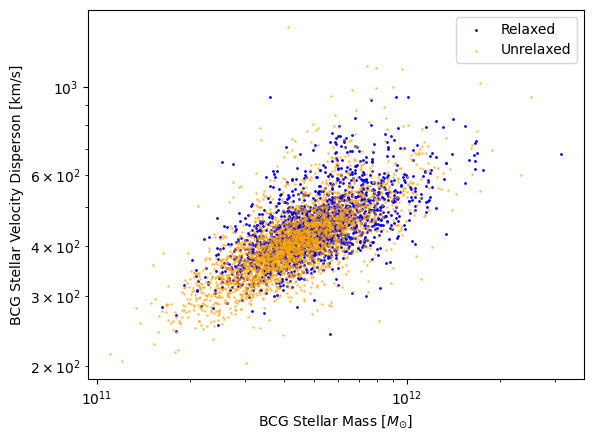

In [16]:
#select columns...
vd_rel = d_relax['halo_properties'].select('vd_stars').get_data()
vd_unrel = d_unrelax['halo_properties'].select('vd_stars').get_data()

#and plot!
plt.scatter(BCG_rel, vd_rel, label = 'Relaxed', color = 'blue', s = 1)
plt.scatter(BCG_unrel, vd_unrel, label = 'Unrelaxed', color = 'orange', s = 1, alpha = 0.5)
plt.ylabel('BCG Stellar Velocity Disperson [km/s]')
plt.xlabel('BCG Stellar Mass [$M_{\odot}$]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

As expected, we get a steady increase in velocity dispersion as mass increases! 

<details>
<summary><b>Your Turn - Gas Velocity Dispersion</b></summary>

Above we only plotted the stellar velocity dispersion. Can you adjust the code to show the same plot but for gas? Try to also make a plot comparing the gas and stellar velocity dispersions to each other.

</details>

Now let's compare the bulk velocity between gas and star particles. Plots like these can help us identify highly disturbed galaxy clusters. The red line is the 1-to-1 line, where the gas and stars are moving with similar bulk velocities.

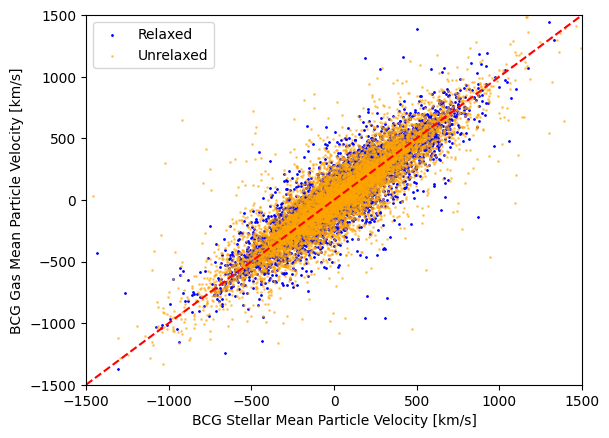

In [17]:
#select gas/star bulk velocity offsets...
vms_rel  = d_relax['halo_properties'].select('vm_stars').get_data()
vms_unrel = d_unrelax['halo_properties'].select('vm_stars').get_data()
vmg_rel  = d_relax['halo_properties'].select('vm_gas').get_data()
vmg_unrel = d_unrelax['halo_properties'].select('vm_gas').get_data()

#plot!
plt.scatter(vms_rel, vmg_rel, label = 'Relaxed', color = 'blue', s = 1)
plt.scatter(vms_unrel, vmg_unrel, label = 'Unrelaxed', color = 'orange', s = 1, alpha = 0.5)
plt.plot([vms_unrel.min(),vms_unrel.max()], [vms_unrel.min(),vms_unrel.max()], linestyle = 'dashed', color = 'r')
plt.xlabel('BCG Stellar Mean Particle Velocity [km/s]')
plt.ylabel('BCG Gas Mean Particle Velocity [km/s]')
plt.xlim(-1500,1500)
plt.ylim(-1500,1500)
plt.legend()
plt.show()

As we can see, many galaxies lie close to the 1-to-1 line, but the scatter indicates clusters that are more likely to be disturbed.